In [ ]:
# Import Pool

import numpy as np               # Importing Numpy Module as 'np'
import pandas as pd              # Importing Pandas Module as 'pd'
import matplotlib.pyplot as plt  # Importing MatPlotLib Module as 'plt'
import seaborn as sns            # Importing Seaborn Module as 'sns'
import plotly.express as px      # Importing Plotly as 'px'

In [ ]:
df = pd.read_excel("gen_chart.xlsx", header = 1)

##Restructuring the Dataset

In [ ]:
df = df.rename(columns={"Unnamed: 1": "Fuel Info"})

In [ ]:
df

,Fuel Type,Fuel Info,1/1/2015 12:00:00 AM,2/1/2015 12:00:00 AM,3/1/2015 12:00:00 AM,4/1/2015 12:00:00 AM,5/1/2015 12:00:00 AM,6/1/2015 12:00:00 AM,7/1/2015 12:00:00 AM,8/1/2015 12:00:00 AM,...,4/1/2025 12:00:00 AM,5/1/2025 12:00:00 AM,6/1/2025 12:00:00 AM,7/1/2025 12:00:00 AM,8/1/2025 12:00:00 AM,9/1/2025 12:00:00 AM,10/1/2025 12:00:00 AM,11/1/2025 12:00:00 AM,12/1/2025 12:00:00 AM,1/1/2026 12:00:00 AM
0,Coal,Maximum Capacity,6271.000000,6271.000000,6271.000000,6271.008333,6277.000000,6277.000000,6277.000000,6277.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Total Generation,4796.605441,4632.713266,4262.546562,3968.257993,3781.066396,4434.964824,4538.924972,4464.016189,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,System Capacity,6271.000000,6271.000000,6271.000000,6271.008333,6277.000000,6277.000000,6277.000000,6277.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,System Available,5649.038978,5330.757440,5188.405914,4563.925000,4662.293011,5338.491667,5362.719086,5081.916667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,System Generation,4801.624184,4636.842688,4269.689325,3973.649076,3783.699140,4439.912644,4545.557564,4469.260905,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Cogeneration,Maximum Capacity,4529.935484,4514.000000,4528.032258,4546.256944,4554.000000,4554.000000,4554.000000,4554.000000,...,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000,6150.733333,6154.000000,6172.096774
6,NaN,Total Generation,3111.933410,3303.774409,3105.026355,2806.126941,2599.254116,2511.522130,2871.597444,2891.172415,...,4137.611785,3542.714034,3855.632503,4076.856146,4062.283664,3570.687234,4083.384565,4826.698114,5285.015738,4950.149581
7,NaN,System Capacity,4032.935484,4017.000000,4031.032258,4042.520833,4047.000000,4047.000000,4047.000000,4047.000000,...,5794.600000,5794.600000,5794.600000,5794.600000,5794.600000,5794.600000,5794.600000,5797.213333,5799.500000,5813.209677
8,NaN,System Available,2931.169355,3024.322917,2860.125000,2644.809722,2413.369624,2184.379167,2494.375000,2561.995968,...,3782.566667,3235.591398,3561.136111,3779.427419,3690.604839,3199.890278,3692.899194,4355.723611,4830.829301,4730.831989
9,NaN,System Generation,1269.039117,1389.688514,1202.562139,1236.971053,1139.499542,1001.756500,1029.744974,1028.122822,...,1939.723361,1546.946020,1740.834963,1820.467069,1721.314110,1340.853015,1731.658975,2265.194785,2566.629784,2313.490805


In [ ]:
df_new = df.melt(
    id_vars=["Fuel Type", "Fuel Info"],
    var_name="Date - MST",
    value_name="Value (MW)"
)

In [ ]:
df_new.head(10)

,Fuel Type,Fuel Info,Date - MST,Value (MW)
0,Coal,Maximum Capacity,1/1/2015 12:00:00 AM,6271.000000
1,NaN,Total Generation,1/1/2015 12:00:00 AM,4796.605441
2,NaN,System Capacity,1/1/2015 12:00:00 AM,6271.000000
3,NaN,System Available,1/1/2015 12:00:00 AM,5649.038978
4,NaN,System Generation,1/1/2015 12:00:00 AM,4801.624184
5,Cogeneration,Maximum Capacity,1/1/2015 12:00:00 AM,4529.935484
6,NaN,Total Generation,1/1/2015 12:00:00 AM,3111.933410
7,NaN,System Capacity,1/1/2015 12:00:00 AM,4032.935484
8,NaN,System Available,1/1/2015 12:00:00 AM,2931.169355
9,NaN,System Generation,1/1/2015 12:00:00 AM,1269.039117


In [ ]:
df_new["Fuel Type"] = df_new["Fuel Type"].ffill()

In [ ]:
df_new

,Fuel Type,Fuel Info,Date - MST,Value (MW)
0,Coal,Maximum Capacity,1/1/2015 12:00:00 AM,6271.000000
1,Coal,Total Generation,1/1/2015 12:00:00 AM,4796.605441
2,Coal,System Capacity,1/1/2015 12:00:00 AM,6271.000000
3,Coal,System Available,1/1/2015 12:00:00 AM,5649.038978
4,Coal,System Generation,1/1/2015 12:00:00 AM,4801.624184
...,...,...,...,...
7310,Wind,Maximum Capacity,1/1/2026 12:00:00 AM,5684.000000
7311,Wind,Total Generation,1/1/2026 12:00:00 AM,2215.253840
7312,Wind,System Capacity,1/1/2026 12:00:00 AM,5676.000000
7313,Wind,System Available,1/1/2026 12:00:00 AM,5368.434140


##Inspecting the Re-Structured Dataset

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7315 entries, 0 to 7314
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fuel Type   7315 non-null   object 
 1   Fuel Info   7315 non-null   object 
 2   Date - MST  7315 non-null   object 
 3   Value (MW)  6020 non-null   float64
dtypes: float64(1), object(3)
memory usage: 228.7+ KB


In [ ]:
df_new.duplicated().sum()

np.int64(0)

In [ ]:
df_new.shape

(7315, 4)

In [ ]:
df_new.isnull().sum()

,0
Fuel Type,0
Fuel Info,0
Date - MST,0
Value (MW),1295


In [ ]:
df_new.dtypes

,0
Fuel Type,object
Fuel Info,object
Date - MST,object
Value (MW),float64


In [ ]:
df_new['Fuel Type'].unique()

array(['Coal', 'Cogeneration', 'Combined Cycle', 'Dual Fuel',
       'Gas Fired Steam', 'Hydro', 'Other', 'Simple Cycle', 'Solar',
       'Storage', 'Wind'], dtype=object)

In [ ]:
df_new['Fuel Info'].unique()

array(['Maximum Capacity', 'Total Generation', 'System Capacity',
       'System Available', 'System Generation'], dtype=object)

##Data Processing for Re-Structured Dataset

In [ ]:
df_new['Date - MST'] = pd.to_datetime(df_new['Date - MST'], format="%Y-%m-%d %H:%M:%S")

In [ ]:
df_2017 = df_new[df_new['Date - MST'].dt.year >= 2017]

In [ ]:
df_2017.head(60)

,Fuel Type,Fuel Info,Date - MST,Value (MW)
1320,Coal,Maximum Capacity,2017-01-01,6299.000000
1321,Coal,Total Generation,2017-01-01,4751.330855
1322,Coal,System Capacity,2017-01-01,6299.000000
1323,Coal,System Available,2017-01-01,5408.548387
1324,Coal,System Generation,2017-01-01,4752.062114
1325,Cogeneration,Maximum Capacity,2017-01-01,4779.000000
1326,Cogeneration,Total Generation,2017-01-01,3426.097072
1327,Cogeneration,System Capacity,2017-01-01,4153.000000
1328,Cogeneration,System Available,2017-01-01,2815.196237
1329,Cogeneration,System Generation,2017-01-01,1336.642948


In [ ]:
df_new['Fuel Type'] = df_new['Fuel Type'].astype('category')
df_new['Fuel Info'] = df_new['Fuel Info'].astype('category')

In [ ]:
df_new.dtypes

,0
Fuel Type,category
Fuel Info,category
Date - MST,datetime64[ns]
Value (MW),float64


In [ ]:
df_new.to_csv("aeso_dataset.csv", index = False)

##EDA for Re-Structured Dataset

In [ ]:
df_gen = df_new[df_new['Fuel Info'] == 'Total Generation']

fuel_generation = (
    df_gen
    .groupby('Fuel Type')['Value (MW)']
    .sum()
    .sort_values(ascending=False)
)

fuel_generation

,Value (MW)
Fuel Type,
Cogeneration,481904.538402
Coal,306947.661702
Combined Cycle,185020.304281
Wind,109175.303166
Gas Fired Steam,60003.750267
Simple Cycle,38089.129061
Other,31116.742594
Hydro,27602.779021
Dual Fuel,17502.270648


In [ ]:
df_system = df_new[df_new['Fuel Info'] == 'System Generation']

system_by_hour = (
    df_system
    .groupby('Date - MST')['Value (MW)']
    .sum()
)

df_system

,Fuel Type,Fuel Info,Date - MST,Value (MW)
4,Coal,System Generation,2015-01-01,4801.624184
9,Cogeneration,System Generation,2015-01-01,1269.039117
14,Combined Cycle,System Generation,2015-01-01,418.164190
19,Dual Fuel,System Generation,2015-01-01,NaN
24,Gas Fired Steam,System Generation,2015-01-01,NaN
...,...,...,...,...
7294,Other,System Generation,2026-01-01,71.746639
7299,Simple Cycle,System Generation,2026-01-01,171.752718
7304,Solar,System Generation,2026-01-01,156.122173
7309,Storage,System Generation,2026-01-01,1.063180


In [ ]:
df_capacity = df_new[df_new['Fuel Info'] == 'Maximum Capacity']
df_generation = df_new[df_new['Fuel Info'] == 'Total Generation']

In [ ]:
df_merged = df_generation.merge(
    df_capacity,
    on=['Date - MST', 'Fuel Type'],
    suffixes=('_gen', '_cap')
)

df_merged['utilization'] = df_merged['Value (MW)_gen'] / df_merged['Value (MW)_cap']

In [ ]:
df_merged

,Fuel Type,Fuel Info_gen,Date - MST,Value (MW)_gen,Fuel Info_cap,Value (MW)_cap,utilization
0,Coal,Total Generation,2015-01-01,4796.605441,Maximum Capacity,6271.000000,0.764887
1,Cogeneration,Total Generation,2015-01-01,3111.933410,Maximum Capacity,4529.935484,0.686971
2,Combined Cycle,Total Generation,2015-01-01,547.520442,Maximum Capacity,1758.000000,0.311445
3,Dual Fuel,Total Generation,2015-01-01,NaN,Maximum Capacity,NaN,NaN
4,Gas Fired Steam,Total Generation,2015-01-01,NaN,Maximum Capacity,NaN,NaN
...,...,...,...,...,...,...,...
1458,Other,Total Generation,2026-01-01,248.418201,Maximum Capacity,437.000000,0.568463
1459,Simple Cycle,Total Generation,2026-01-01,188.636364,Maximum Capacity,934.000000,0.201966
1460,Solar,Total Generation,2026-01-01,154.870578,Maximum Capacity,1860.967742,0.083220
1461,Storage,Total Generation,2026-01-01,-1.650317,Maximum Capacity,190.000000,-0.008686


##EDA Visualizations on Re-Structured Dataset

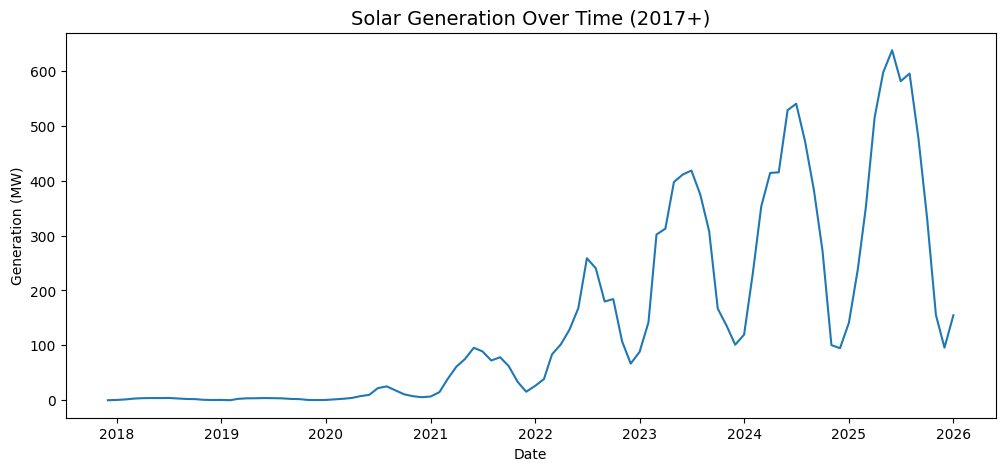

In [ ]:
solar_gen = df_2017[(df_2017['Fuel Type'] == 'Solar') & (df_2017['Fuel Info'] == 'Total Generation')]

# Plot
plt.figure(figsize=(12,5))
sns.lineplot(data=solar_gen, x='Date - MST', y='Value (MW)')
plt.title('Solar Generation Over Time (2017+)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.show()

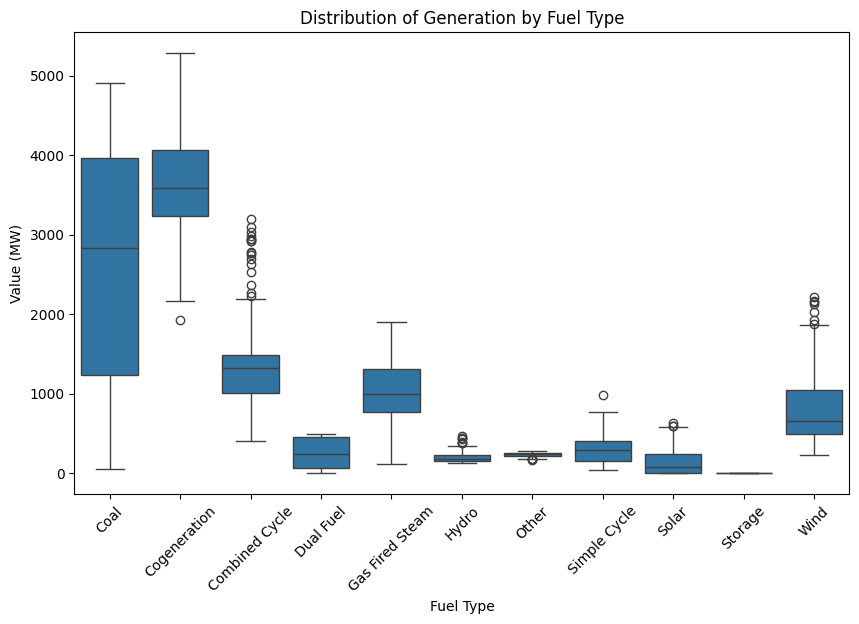

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_gen, x='Fuel Type', y='Value (MW)')
plt.title('Distribution of Generation by Fuel Type')
plt.xticks(rotation=45)
plt.show()

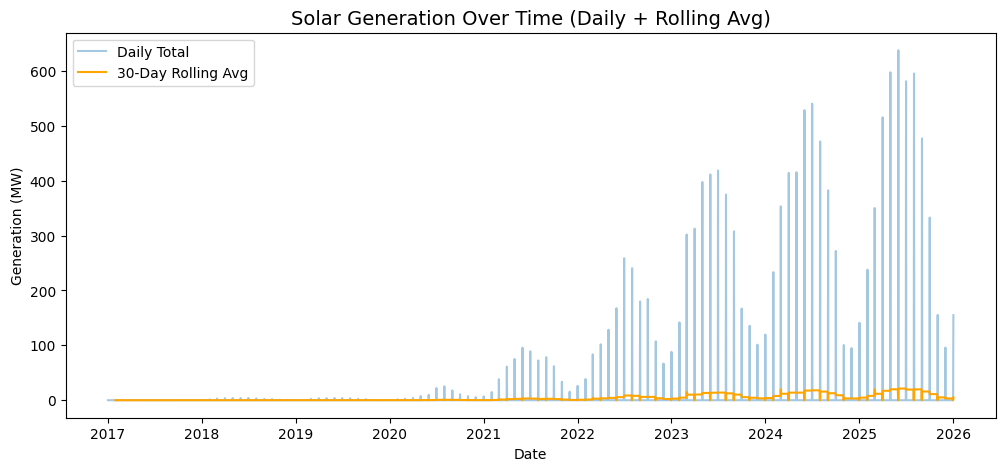

In [ ]:
solar_daily = solar_gen.set_index('Date - MST')['Value (MW)'].resample('D').sum()
solar_daily_rolling = solar_daily.rolling(window=30).mean()  # 30-day rolling average

plt.figure(figsize=(12,5))
plt.plot(solar_daily.index, solar_daily, alpha=0.4, label='Daily Total')
plt.plot(solar_daily_rolling.index, solar_daily_rolling, color='orange', label='30-Day Rolling Avg')
plt.title('Solar Generation Over Time (Daily + Rolling Avg)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.legend()
plt.show()

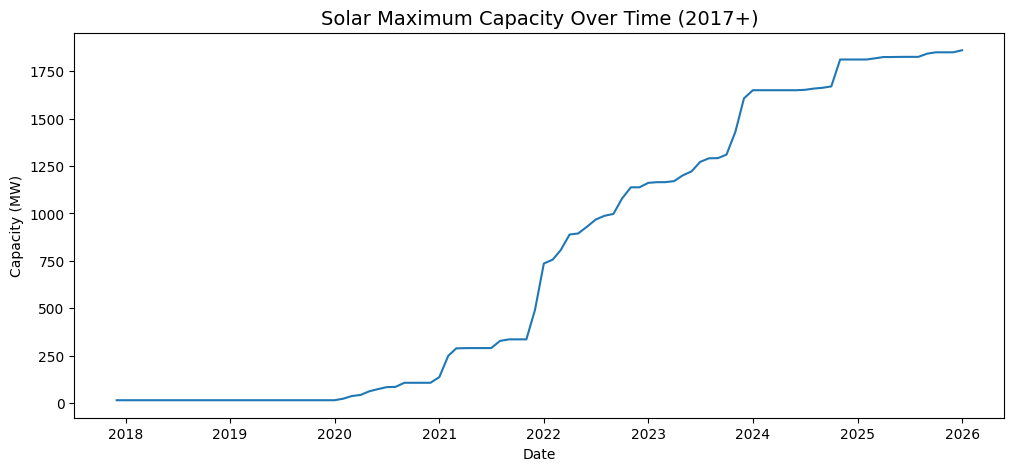

In [ ]:
solar_gen_sys = df_2017[(df_2017['Fuel Type'] == 'Solar') & (df_2017['Fuel Info'] == 'Maximum Capacity')]

# Plot
plt.figure(figsize=(12,5))
sns.lineplot(data=solar_gen_sys, x='Date - MST', y='Value (MW)')
plt.title('Solar Maximum Capacity Over Time (2017+)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Capacity (MW)')
plt.show()

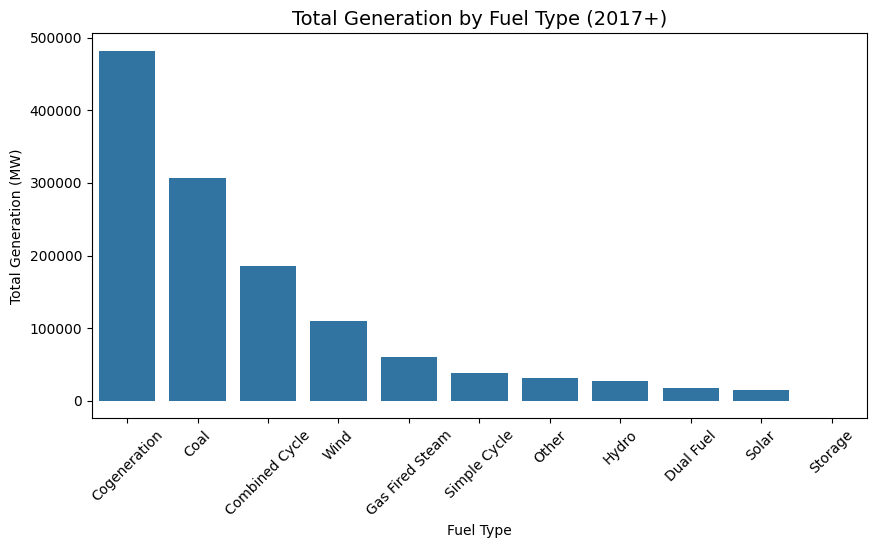

In [ ]:
fuel_totals = df_gen.groupby('Fuel Type')['Value (MW)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=fuel_totals.index, y=fuel_totals.values)
plt.title('Total Generation by Fuel Type (2017+)', fontsize=14)
plt.ylabel('Total Generation (MW)')
plt.xticks(rotation=45)
plt.show()

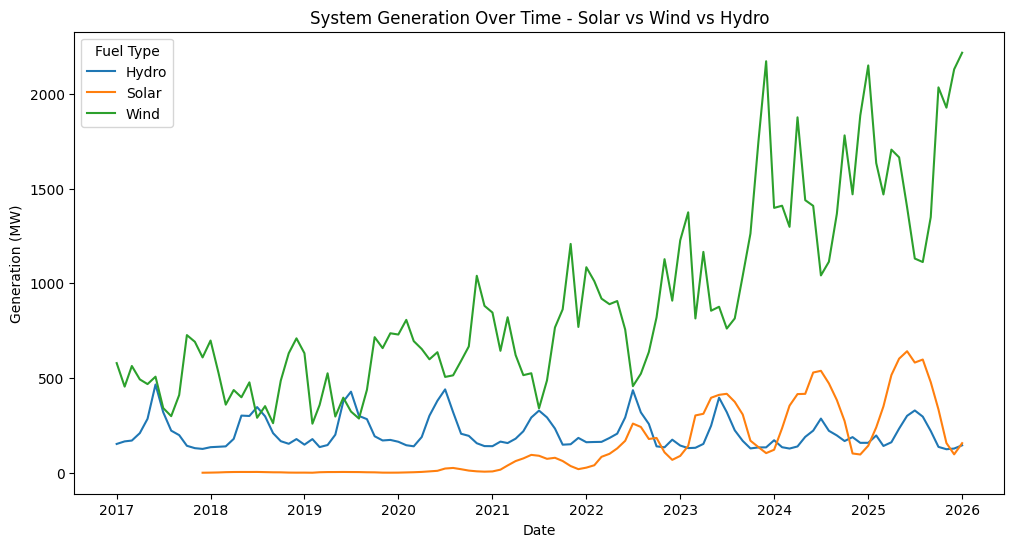

In [ ]:
fuel_compare_list = ['Solar', 'Wind', 'Hydro']

# Filter dataframe
df_subset = df_2017[
    (df_2017['Fuel Type'].isin(fuel_compare_list)) &
    (df_2017['Fuel Info'] == 'System Generation')
]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_subset, x='Date - MST', y='Value (MW)', hue='Fuel Type')
plt.title('System Generation Over Time - Solar vs Wind vs Hydro')
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.legend(title='Fuel Type')
plt.show()

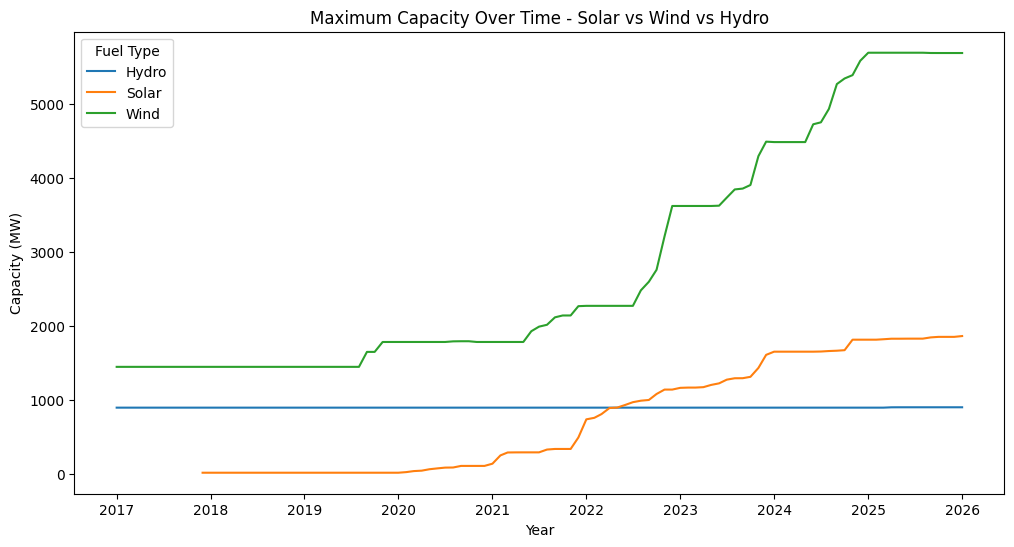

In [ ]:
fuel_compare_list = ['Solar', 'Wind', 'Hydro']

# Filter dataframe
df_subset = df_2017[
    (df_2017['Fuel Type'].isin(fuel_compare_list)) &
    (df_2017['Fuel Info'] == 'Maximum Capacity')
]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_subset, x='Date - MST', y='Value (MW)', hue='Fuel Type')
plt.title('Maximum Capacity Over Time - Solar vs Wind vs Hydro')
plt.xlabel('Year')
plt.ylabel('Capacity (MW)')
plt.legend(title='Fuel Type')
plt.show()

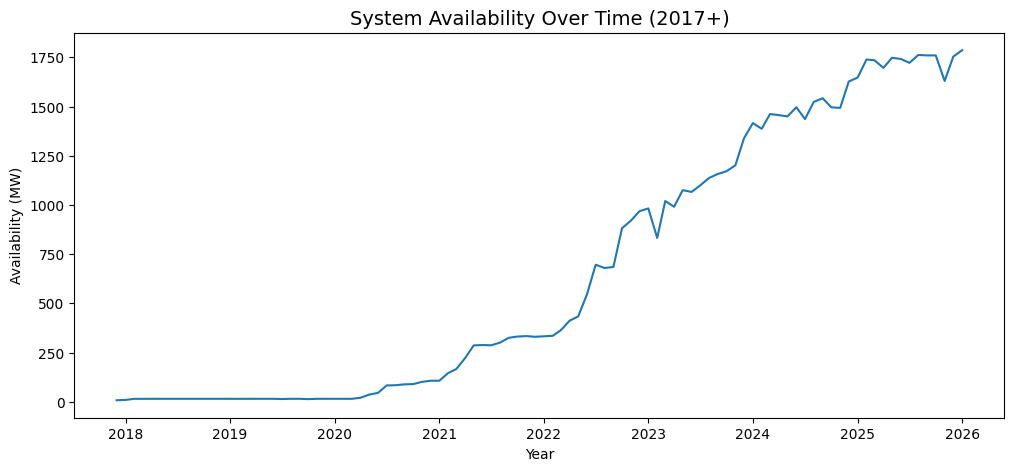

In [ ]:
solar_gen = df_2017[(df_2017['Fuel Type'] == 'Solar') & (df_2017['Fuel Info'] == 'System Available')]

# Plot
plt.figure(figsize=(12,5))
sns.lineplot(data=solar_gen, x='Date - MST', y='Value (MW)')
plt.title('System Availability Over Time (2017+)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Availability (MW)')
plt.show()

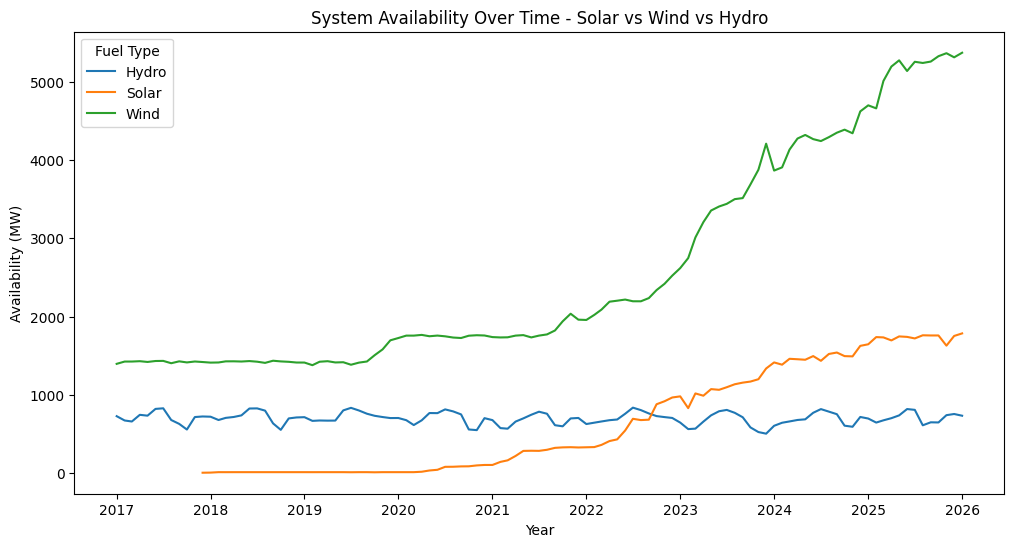

In [ ]:
fuel_compare_list = ['Solar', 'Wind', 'Hydro']

# Filter dataframe
df_subset = df_2017[
    (df_2017['Fuel Type'].isin(fuel_compare_list)) &
    (df_2017['Fuel Info'] == 'System Available')
]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_subset, x='Date - MST', y='Value (MW)', hue='Fuel Type')
plt.title('System Availability Over Time - Solar vs Wind vs Hydro')
plt.xlabel('Year')
plt.ylabel('Availability (MW)')
plt.legend(title='Fuel Type')
plt.show()